В этом ноутбуке представлено исследование, на основании которого было сделано дипломное решение.


-----

In [ ]:
!pip install seaborn matplotlib pandas numpy catboost scikit-learn imblearn openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]




[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [ ]:

# Показать все строки и столбцы при выводе DataFrame
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

## Модель для предсказания типа исходного органического вещества

##### Mодель для предсказаний типа органического вещества для керогена 

будем использовать только значение Total для предсказания, так как при исследовании изопотного состава керогена не делют разделение по фракциям

In [10]:
data_kerogen = pd.read_excel('kerogen_data.xlsx')

X_train, X_test_kerogen, y_train, y_test_kerogen = train_test_split(
    data_kerogen[['Total']],
    data_kerogen['organic_matter'],
    test_size=0.2,
    random_state=42,
    stratify=data_kerogen['organic_matter']
)           


X_train_kerogen, X_val_kerogen, y_train_kerogen, y_val_kerogen = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)  

In [11]:
y_test_kerogen.value_counts()

organic_matter
морское         87
смешанное ов    24
террагенное      5
Name: count, dtype: int64

In [12]:
le = LabelEncoder()
y_train_kerogen_encoded = le.fit_transform(y_train_kerogen)  
y_val_kerogen_encoded = le.transform(y_val_kerogen)
y_test_kerogen_encoded = le.transform(y_test_kerogen)


model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=3,
    loss_function='MultiClass',         
    eval_metric='TotalF1',              
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_kerogen, y_train_kerogen_encoded,
    eval_set=(X_val_kerogen, y_val_kerogen_encoded),
    verbose=10
)


y_pred_kerogen = model.predict(X_test_kerogen)
y_pred_proba_kerogen = model.predict_proba(X_test_kerogen)  


print("weighted_f1",  f1_score(y_test_kerogen_encoded, y_pred_kerogen, average='weighted'))
print("\nClassification Report:")
print(classification_report(y_test_kerogen_encoded, y_pred_kerogen))


model.save_model("catboost_multiclass_organic_matter_kerogen.cbm")
y_pred_labels = le.inverse_transform(y_pred_kerogen)

0:	learn: 0.9633817	test: 0.9788251	best: 0.9788251 (0)	total: 1.13ms	remaining: 112ms
10:	learn: 0.9839046	test: 1.0000000	best: 1.0000000 (5)	total: 16.7ms	remaining: 135ms
20:	learn: 0.9892635	test: 1.0000000	best: 1.0000000 (5)	total: 27.4ms	remaining: 103ms
30:	learn: 0.9918779	test: 1.0000000	best: 1.0000000 (5)	total: 38.3ms	remaining: 85.3ms
40:	learn: 0.9945592	test: 1.0000000	best: 1.0000000 (5)	total: 50.9ms	remaining: 73.3ms
50:	learn: 0.9945592	test: 1.0000000	best: 1.0000000 (5)	total: 63.8ms	remaining: 61.3ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 5

Shrink model to first 6 iterations.
weighted_f1 0.9830032076984763

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        87
           1       0.92      1.00      0.96        24
           2       1.00      1.00      1.00         5

    accuracy                           0.98       116
   macro avg       0

c:\Users\Настя\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


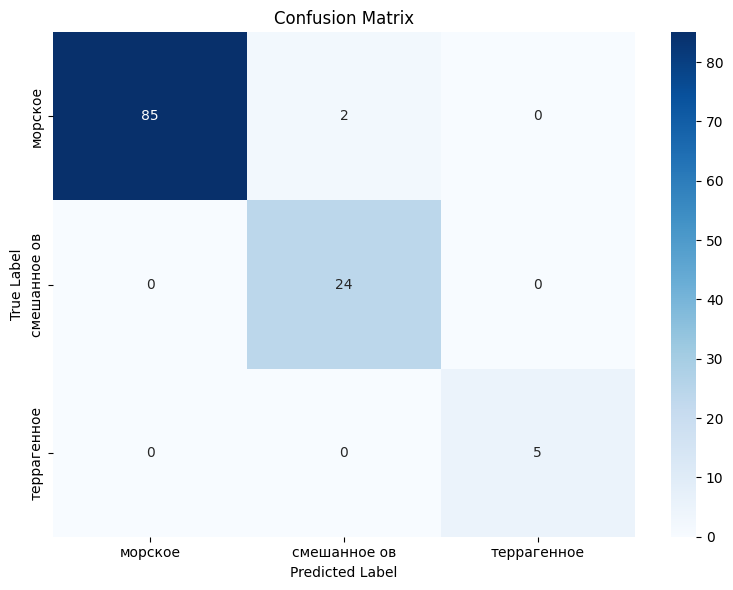

In [13]:
cm = confusion_matrix(y_test_kerogen_encoded, y_pred_kerogen)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_kerogen), 
            yticklabels=np.unique(y_test_kerogen))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [14]:
df_pred = pd.DataFrame({
    'y_true': y_test_kerogen_encoded,
    'y_pred': y_pred_kerogen.reshape(-1,),
})
df_pred.index = X_test_kerogen.index 


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba_kerogen.shape[1])]
df_proba = pd.DataFrame(y_pred_proba_kerogen, columns=prob_columns, index=X_test_kerogen.index)


df_pred = pd.concat([df_pred, X_test_kerogen, df_proba], axis=1)


misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index(inplace=True)

misclassified

,y_true,y_pred,Total,prob_class_0,prob_class_1,prob_class_2
477,0,1,-28.0,0.305362,0.434455,0.260183
545,0,1,-28.0,0.305362,0.434455,0.260183


0 - морское
1 - смешанное
2 - терригенное

#### Mодель для предсказания типа ов для нефти и битумоида

In [4]:
df = pd.read_excel('dataset.xlsx').set_index('№')
df

,Sat,Aro,Res,Asph,B-Res,SB-Res,Total,Total OM,organic_matter,mean,...,heavy-light,min(heavy)-min(light),min(heavy)-max(light),min(heavy)-mean(light),oxidation,biodegredation,thermal_alteration,migration_out,migration_in,степень преобразованности
№,,,,,,,,,,,,,,,,,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,-26.044455,-26.144510,NaN,NaN,смешанное ов,-26.284299,...,0.955593,1.558101,-0.033057,0.762522,0.0,0.0,0.0,0.0,0.0,high
231,-29.405211,-26.059587,-25.656453,-25.987500,-24.599474,-26.713432,NaN,NaN,смешанное ов,-26.403609,...,1.910423,3.417711,0.072087,1.744899,0.0,0.0,0.0,0.0,1.0,low
232,-30.561385,-28.704900,-28.300707,-27.909181,-28.165632,-28.435782,NaN,NaN,морское,-28.679598,...,1.528199,2.260678,0.404193,1.332436,0.0,0.0,0.0,0.0,1.0,high
233,-31.602036,-30.805939,-27.730244,-28.712895,-28.099024,-27.361463,NaN,NaN,морское,-29.051934,...,2.982419,2.889142,2.093045,2.491093,0.0,0.0,0.0,0.0,1.0,high
234,-27.340295,-30.127533,-29.691479,-28.045461,-29.676470,-29.706487,NaN,NaN,морское,-29.097954,...,-0.134556,0.436054,-2.351184,-0.957565,0.0,1.0,1.0,1.0,0.0,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,NaN,NaN,-32.9,NaN,морское,NaN,...,0.600000,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN
2088,-33.900000,-33.100000,-34.900000,NaN,NaN,NaN,-34.3,NaN,морское,NaN,...,-1.400000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2089,-34.000000,-33.300000,NaN,NaN,NaN,NaN,-33.7,NaN,морское,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN


In [38]:
data = df[['Sat', 'Aro', 'Res', 'Asph', 'B-Res', 'SB-Res', 'Total', 'Total OM', 'organic_matter']]
data


,Sat,Aro,Res,Asph,B-Res,SB-Res,Total,Total OM,organic_matter
№,,,,,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,-26.044455,-26.144510,NaN,NaN,смешанное ов
231,-29.405211,-26.059587,-25.656453,-25.987500,-24.599474,-26.713432,NaN,NaN,смешанное ов
232,-30.561385,-28.704900,-28.300707,-27.909181,-28.165632,-28.435782,NaN,NaN,морское
233,-31.602036,-30.805939,-27.730244,-28.712895,-28.099024,-27.361463,NaN,NaN,морское
234,-27.340295,-30.127533,-29.691479,-28.045461,-29.676470,-29.706487,NaN,NaN,морское
...,...,...,...,...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,NaN,NaN,-32.9,NaN,морское
2088,-33.900000,-33.100000,-34.900000,NaN,NaN,NaN,-34.3,NaN,морское
2089,-34.000000,-33.300000,NaN,NaN,NaN,NaN,-33.7,NaN,морское


Выше видели, что в данных есть пропуски. Рассмотрим несколько случаев заполнения пропусков:  
- В случае, если нет результатов исследований для Sat, Aro, Asph, B-Res	и SB-Res удаляем строки, так как заполнить средним/модой/медианой неверно с точки зрения геологии
- Данные есть для B-Res	и SB-Res, но для Res данных нет - Res = (B-Res + SB-Res)/2
- Если нет данных для Total, то ищем среднеарифметическое по строке  


По сути для всех предсказаний будем использовать столбцы Sat, Aro, Asph, Res и Total  

Заполним пропуски



In [39]:
# заполним пропуски в 'Res' средним значением 'B-Res' и 'SB-Res'
mask = data['Res'].isna()
data.loc[mask, 'Res'] = (data.loc[mask, 'B-Res'] + data.loc[mask, 'SB-Res']) / 2

# заполним пропуски в 'Total' значением 'Total OM'
mask_total = data['Total'].isna()
data.loc[mask_total, 'Total'] = data.loc[mask_total, 'Total OM']

# заполним пропуски в 'Total' среднеарифметическим всех остальных фракций
mask_total = data['Total'].isna()
data.loc[mask_total, 'Total'] = data.loc[mask_total, ['Sat', 'Aro', 'Res', 'Asph', 'B-Res', 'SB-Res']].mean(axis=1)



In [40]:
data


,Sat,Aro,Res,Asph,B-Res,SB-Res,Total,Total OM,organic_matter
№,,,,,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,-26.044455,-26.144510,-26.284299,NaN,смешанное ов
231,-29.405211,-26.059587,-25.656453,-25.987500,-24.599474,-26.713432,-26.403609,NaN,смешанное ов
232,-30.561385,-28.704900,-28.300707,-27.909181,-28.165632,-28.435782,-28.679598,NaN,морское
233,-31.602036,-30.805939,-27.730244,-28.712895,-28.099024,-27.361463,-29.051934,NaN,морское
234,-27.340295,-30.127533,-29.691479,-28.045461,-29.676470,-29.706487,-29.097954,NaN,морское
...,...,...,...,...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,NaN,NaN,-32.9,NaN,морское
2088,-33.900000,-33.100000,-34.900000,NaN,NaN,NaN,-34.3,NaN,морское
2089,-34.000000,-33.300000,NaN,NaN,NaN,NaN,-33.7,NaN,морское


In [41]:
# выделим признаки для модели, предсказывающей 'organic_matter' и удалим оставшиеся пропуски
data_organic = data[['Sat', 'Aro', 'Res', 'Asph', 'Total', 'organic_matter']]
data_organic_cleaned = data_organic.dropna()
data_organic_cleaned.isna().sum()

Sat               0
Aro               0
Res               0
Asph              0
Total             0
organic_matter    0
dtype: int64

In [42]:
data_organic_cleaned.organic_matter.value_counts()

organic_matter
морское         387
смешанное ов    161
террагенное       5
Name: count, dtype: int64

Видим дисбаланс классов organic_matter. Нагенерируем синтетические данные с помощью SMOTE методики

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    data_organic_cleaned.drop('organic_matter', axis=1),
    data_organic_cleaned['organic_matter'],
    test_size=0.2,
    random_state=42,
    stratify=data_organic_cleaned['organic_matter']
)           


X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)  


smote = SMOTE(k_neighbors=2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
y_train_resampled.value_counts() 

organic_matter
морское         247
смешанное ов    247
террагенное     247
Name: count, dtype: int64

будем использовать признаки 'Sat', 'Aro', 'Res', 'Asph'

In [44]:
X_train_oil_bitumoid = X_train_resampled[['Sat', 'Aro', 'Res', 'Asph']]
X_test_oil_bitumoid = X_test[['Sat', 'Aro', 'Res', 'Asph']]
X_val_oil_bitumoid = X_val[['Sat', 'Aro', 'Res', 'Asph']]


In [45]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_train_resampled)  
y_test_encoded = le.transform(y_test)
y_val_encoded = le.transform(y_val)


model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',         
    eval_metric='TotalF1:average=Macro',            
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_oil_bitumoid, y_encoded,
    eval_set=(X_val_oil_bitumoid, y_val_encoded),
    verbose=100
)


y_pred_oil_bitumoid = model.predict(X_test_oil_bitumoid)
y_pred_proba_oil_bitumoid = model.predict_proba(X_test_oil_bitumoid)  


print("weighted_f1",  f1_score(y_test_encoded, y_pred_oil_bitumoid, average='weighted'))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_oil_bitumoid))


model.save_model("catboost_multiclass_organic_matter_oil_bitumoid.cbm")

y_pred_labels = le.inverse_transform(y_pred_oil_bitumoid)

0:	learn: 0.9716403	test: 0.9550033	best: 0.9550033 (0)	total: 7.86ms	remaining: 3.92s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.971717821
bestIteration = 8

Shrink model to first 9 iterations.
weighted_f1 0.9454162206305939

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        78
           1       0.93      0.88      0.90        32
           2       1.00      1.00      1.00         1

    accuracy                           0.95       111
   macro avg       0.96      0.95      0.96       111
weighted avg       0.95      0.95      0.95       111



c:\Users\Настя\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


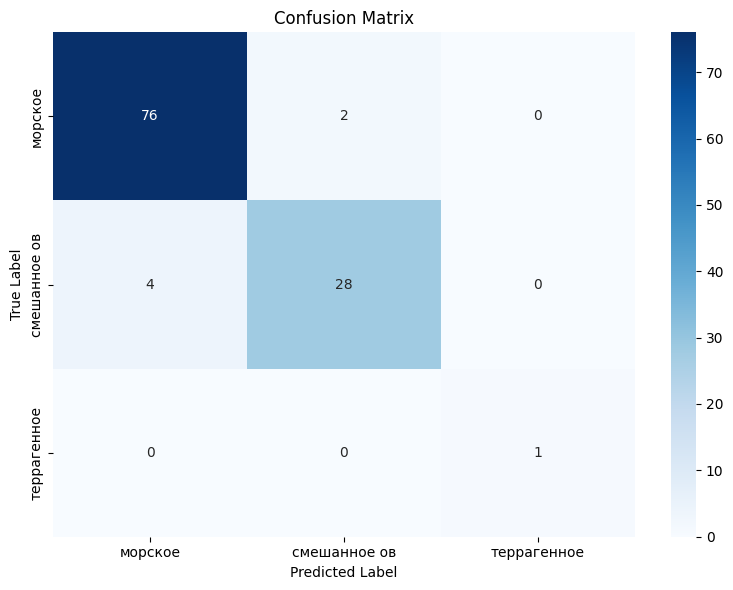

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


cm = confusion_matrix(y_test_encoded, y_pred_oil_bitumoid)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [49]:
df_pred = pd.DataFrame({
    'y_true': y_test_encoded,
    'y_pred': y_pred_oil_bitumoid.reshape(-1,),
})
df_pred.index = X_test_oil_bitumoid.index 


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba_kerogen.shape[1])]
df_proba = pd.DataFrame(y_pred_proba_oil_bitumoid, columns=prob_columns, index=X_test_oil_bitumoid.index)


df_pred = pd.concat([df_pred, X_test_oil_bitumoid, df_proba], axis=1)


misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index(inplace=True)

misclassified

,y_true,y_pred,Sat,Aro,Res,Asph,prob_class_0,prob_class_1,prob_class_2
№,,,,,,,,,
543,1,0,-29.949245,-29.522636,-28.780000,-27.600000,0.420613,0.340859,0.238529
585,0,1,-28.720000,-27.740000,-27.990000,-28.490000,0.359691,0.399157,0.241152
617,1,0,-29.270000,-28.903420,-29.092284,-28.250698,0.528227,0.248107,0.223667
618,1,0,-28.867897,-28.875094,-28.977264,-27.743235,0.408858,0.344956,0.246187
650,1,0,-29.810000,-28.660000,-29.180000,-25.890000,0.379030,0.370910,0.250060
1851,0,1,-29.580000,-28.780000,-28.150000,-28.040000,0.323787,0.445893,0.230320


# Модель для предсказания термической преобразованности, биодеградации и миграции (уход флюида)

In [50]:
data_thermal_alteration = df[['Sat', 'Aro', 'Res', 'Asph', 'B-Res', 'SB-Res', 'thermal_alteration']]


In [ ]:

# выкинем строки с пропусками данных фракций, по которым нельзя определить, была ли термическое воздействие
# при каждом из процессов изменяется определнная фракция (несколько фракций), если я при разметке данных могу определить процесс с missing data, то его оставляем
# будем использовать методы, которые могут работать с пропусками
data_thermal_alteration = data_thermal_alteration.dropna(subset=['thermal_alteration'])

# для предсказания будем использовать фракции (Sat, Aro, Res, Asph) и их разности + разности легких и тяжелых фракций. Если данных для Res нет, заполним их средним значением B-Res и SB-Res
mask = data_thermal_alteration['Res'].isna()
data_thermal_alteration.loc[mask, 'Res'] = (data_thermal_alteration.loc[mask, 'B-Res'] + data_thermal_alteration.loc[mask, 'SB-Res']) / 2
data_thermal_alteration_pred = data_thermal_alteration[['Sat', 'Aro', 'Res', 'Asph', 'thermal_alteration']]
print("Пропуски в данных по термическому воздеействию:\n", data_thermal_alteration_pred.isna().sum())
data_thermal_alteration_pred.value_counts('thermal_alteration')

Пропуски в данных по термическому воздеействию:
 Sat                     0
Aro                     0
Res                    38
Asph                  134
thermal_alteration      0
dtype: int64


thermal_alteration
0.0    565
1.0    147
Name: count, dtype: int64

In [52]:
data_thermal_alteration_pred

,Sat,Aro,Res,Asph,thermal_alteration
№,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,0.0
231,-29.405211,-26.059587,-25.656453,-25.987500,0.0
232,-30.561385,-28.704900,-28.300707,-27.909181,0.0
233,-31.602036,-30.805939,-27.730244,-28.712895,0.0
234,-27.340295,-30.127533,-29.691479,-28.045461,1.0
...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,1.0
2088,-33.900000,-33.100000,-34.900000,NaN,0.0
2089,-34.000000,-33.300000,NaN,NaN,0.0


видим 2 основные проблемы:
1. Очень много пропусков в данных по термическому преобразованию
2. Несбалансированные классы: большинство образцов без термического преобразования  

Выкидывать данные я не хочу, так как их и так мало. Попробую несколько способов восстановления пропусков (IterativeImputer, KNNImputer).  
Сделаю с каждым методом свой датасет, обучу модели с одинаковыми гиперпараметрами и выберу лучший способ по метрикам на тестовой выборке

попробуем сначала не использовать заполнение пропусков, не генерить новые данные 


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data_thermal_alteration_pred.drop('thermal_alteration', axis=1),
    data_thermal_alteration_pred['thermal_alteration'],
    test_size=0.2,
    random_state=42,
    stratify=data_thermal_alteration_pred['thermal_alteration']
) 

X_train_, X_val, y_train_, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 

#заполним пропуски с Iterative Imputer
IterImputer=IterativeImputer()
X_train_imputed = IterImputer.fit_transform(X_train_) 
X_test_imputed = IterImputer.transform(X_test)
X_val_imputed = IterImputer.transform(X_val)

#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train_)
feature_names = X_train.columns

X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_names)
X_val_imputed = pd.DataFrame(X_val_imputed, columns=feature_names)


X_train_['asph-res'] = X_train_['Asph'] - X_train_['Res']
X_train_['res-aro'] = X_train_['Res'] - X_train_['Aro']
X_train_['aro-sat'] = X_train_['Aro'] - X_train_['Sat']
X_train_['heavy-light'] = ((X_train_['Asph'] + X_train_['Res']) / 2) - ((X_train_['Sat'] + X_train_['Aro']) / 2)

X_test['asph-res'] = X_test['Asph'] - X_test['Res']
X_test['res-aro'] = X_test['Res'] - X_test['Aro']
X_test['aro-sat'] = X_test['Aro'] - X_test['Sat']
X_test['heavy-light'] = ((X_test['Asph'] + X_test['Res']) / 2) - ((X_test['Sat'] + X_test['Aro']) / 2)

X_val['asph-res'] = X_val['Asph'] - X_val['Res']
X_val['res-aro'] = X_val['Res'] - X_val['Aro']
X_val['aro-sat'] = X_val['Aro'] - X_val['Sat']
X_val['heavy-light'] = ((X_val['Asph'] + X_val['Res']) / 2) - ((X_val['Sat'] + X_val['Aro']) / 2)


X_train_resampled['asph-res'] = X_train_resampled['Asph'] - X_train_resampled['Res']
X_train_resampled['res-aro'] = X_train_resampled['Res'] - X_train_resampled['Aro']
X_train_resampled['aro-sat'] = X_train_resampled['Aro'] - X_train_resampled['Sat']
X_train_resampled['heavy-light'] = ((X_train_resampled['Asph'] + X_train_resampled['Res']) / 2) - ((X_train_resampled['Sat'] + X_train_resampled['Aro']) / 2)

#xy_smote = pd.concat([X_train_resampled, y_train_resampled], axis=1)
#xy_smote.to_excel('therm.xlsx')
X_test_imputed['asph-res'] = X_test_imputed['Asph'] - X_test_imputed['Res']
X_test_imputed['res-aro'] = X_test_imputed['Res'] - X_test_imputed['Aro']
X_test_imputed['aro-sat'] = X_test_imputed['Aro'] - X_test_imputed['Sat']
X_test_imputed['heavy-light'] = ((X_test_imputed['Asph'] + X_test_imputed['Res']) / 2) - ((X_test_imputed['Sat'] + X_test_imputed['Aro']) / 2)


X_val_imputed['asph-res'] = X_val_imputed['Asph'] - X_val_imputed['Res']
X_val_imputed['res-aro'] = X_val_imputed['Res'] - X_val_imputed['Aro']
X_val_imputed['aro-sat'] = X_val_imputed['Aro'] - X_val_imputed['Sat']
X_val_imputed['heavy-light'] = ((X_val_imputed['Asph'] + X_val_imputed['Res']) / 2) - ((X_val_imputed['Sat'] + X_val_imputed['Aro']) / 2)

In [104]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

#загоняем в модель строки c пропусками


model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='F1',  
    auto_class_weights='Balanced',             
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_, y_train_,
    eval_set=[(X_val, y_val)],
    #plot=True,
    verbose=100
)


#y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test) 
y_pred = (y_pred_proba[:, 1] > 0.6).astype(int) # я тестировала сначала без порога, качество было значительно хуже, поэтому его добавила


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


model.save_model("catboost_thermal_alteration_no_imputer.cbm")


0:	learn: 0.9611921	test: 0.9345179	best: 0.9345179 (0)	total: 3.72ms	remaining: 1.86s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9778589092
bestIteration = 15

Shrink model to first 16 iterations.

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99       113
         1.0       0.91      1.00      0.95        30

    accuracy                           0.98       143
   macro avg       0.95      0.99      0.97       143
weighted avg       0.98      0.98      0.98       143



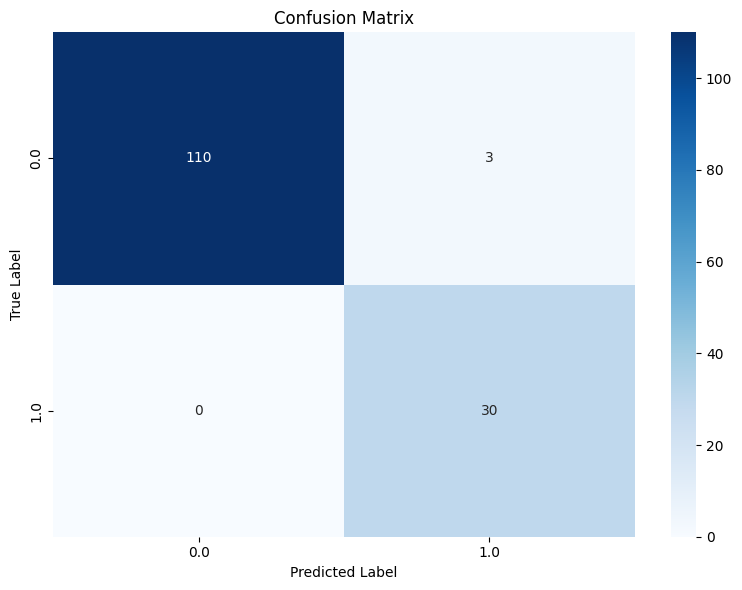

In [105]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [106]:
df_pred = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test.index)



y_prob = model.predict_proba(X_test)[:,1]
print("macro_f1",  f1_score(y_test, y_pred, average='macro'))



threshold = 0.6
y_pred_new = pd.DataFrame((y_prob > threshold).astype(int), columns=['y_pred_new'], index=X_test.index)
print("macro_f1",  f1_score(y_test, y_pred_new['y_pred_new'], average='macro'))


df_pred = pd.concat([df_pred, X_test, df_proba, y_pred_new], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred_new']]
misclassified.sort_index()

macro_f1 0.969464018791373
macro_f1 0.969464018791373


,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,heavy-light,prob_class_0,prob_class_1,y_pred_new
№,,,,,,,,,,,,,
945,0.0,1,-30.540000,-30.710000,-28.620000,NaN,NaN,2.090000,-0.170000,NaN,0.137163,0.862837,1
1403,0.0,1,-29.259555,-29.242802,-29.281338,-30.31507,-1.033733,-0.038536,0.016753,-0.547026,0.340087,0.659913,1
2015,0.0,1,-28.030000,-28.650000,-26.700000,-26.93000,-0.230000,1.950000,-0.620000,1.525000,0.272960,0.727040,1


In [107]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,aro-sat,87.528947
1,heavy-light,4.534379
2,res-aro,1.782636
3,Sat,1.534321
4,Res,1.368509
5,Aro,1.139440
6,asph-res,1.067343
7,Asph,1.044425


попробуем загнать данные с IterativeImputer + Smote

In [108]:

#IterativeImputer + Smote

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    auto_class_weights='Balanced',
    eval_metric='F1',
    early_stopping_rounds=100,
    random_seed=42
)


model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_val_imputed, y_val),
    verbose=100
    
)


y_pred = model.predict(X_test_imputed)
y_pred_proba = model.predict_proba(X_test_imputed)  

threshold = 0.6
y_prob = model.predict_proba(X_test_imputed)[:,1]
print("weighted_f1",  f1_score(y_test, y_pred, average='macro'))
y_pred_new = pd.DataFrame((y_prob > threshold).astype(int), columns=['y_pred_new'], index=X_test.index)
print("weighted_f1",  f1_score(y_test, y_pred_new['y_pred_new'], average='macro'))



print("\nClassification Report:")
print(classification_report(y_test, y_pred))


#model.save_model("catboost_thermal_alteration_iterative_imputer.cbm")


0:	learn: 0.9710345	test: 0.9387755	best: 0.9387755 (0)	total: 4.44ms	remaining: 2.21s
100:	learn: 0.9986169	test: 0.9361702	best: 0.9583333 (12)	total: 303ms	remaining: 1.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9583333333
bestIteration = 12

Shrink model to first 13 iterations.
weighted_f1 0.968743169398907
weighted_f1 0.9789085545722713

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       113
         1.0       0.94      0.97      0.95        30

    accuracy                           0.98       143
   macro avg       0.96      0.97      0.97       143
weighted avg       0.98      0.98      0.98       143



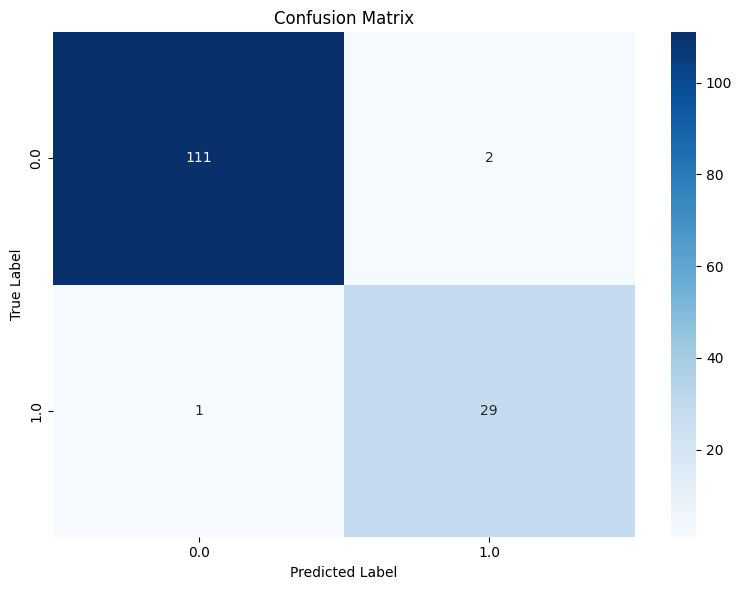

In [109]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [95]:

df_pred = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test.index)


df_pred = pd.concat([df_pred, X_test, df_proba], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,heavy-light,prob_class_0,prob_class_1
№,,,,,,,,,,,,
1854,1.0,0.0,-28.13,-28.13,-27.34,-26.07,1.27,0.79,0.00,1.425,0.727851,0.272149
2015,0.0,1.0,-28.03,-28.65,-26.70,-26.93,-0.23,1.95,-0.62,1.525,0.362240,0.637760


KNNImputer

In [115]:
from sklearn.impute import KNNImputer



knn_imputer=KNNImputer(n_neighbors=5)

X_train_knn_imputed = knn_imputer.fit_transform(X_train_) 
X_test_knn_imputed = knn_imputer.transform(X_test)
X_val_knn_imputed = knn_imputer.transform(X_val)

feature_names = X_train_.columns
X_test_knn_imputed = pd.DataFrame(X_test_knn_imputed, columns=feature_names)
X_val_knn_imputed = pd.DataFrame(X_val_knn_imputed, columns=feature_names)
    
#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_knn_resampled, y_train_resampled = smote.fit_resample(X_train_knn_imputed, y_train_) 
X_train_knn_resampled = pd.DataFrame(X_train_knn_resampled, columns=feature_names)




X_train_knn_resampled['asph-res'] = X_train_knn_resampled['Asph'] - X_train_knn_resampled['Res']
X_train_knn_resampled['res-aro'] = X_train_knn_resampled['Res'] - X_train_knn_resampled['Aro']
X_train_knn_resampled['aro-sat'] = X_train_knn_resampled['Aro'] - X_train_knn_resampled['Sat']
X_train_knn_resampled['heavy-light'] = ((X_train_knn_resampled['Asph'] + X_train_knn_resampled['Res']) / 2) - ((X_train_knn_resampled['Sat'] + X_train_knn_resampled['Aro']) / 2)

#xy_smote = pd.concat([X_train_resampled, y_train_resampled], axis=1)
#xy_smote.to_excel('therm.xlsx')
X_test_knn_imputed['asph-res'] = X_test_knn_imputed['Asph'] - X_test_knn_imputed['Res']
X_test_knn_imputed['res-aro'] = X_test_knn_imputed['Res'] - X_test_knn_imputed['Aro']
X_test_knn_imputed['aro-sat'] = X_test_knn_imputed['Aro'] - X_test_knn_imputed['Sat']
X_test_knn_imputed['heavy-light'] = ((X_test_knn_imputed['Asph'] + X_test_knn_imputed['Res']) / 2) - ((X_test_knn_imputed['Sat'] + X_test_knn_imputed['Aro']) / 2)

X_val_knn_imputed['asph-res'] = X_val_knn_imputed['Asph'] - X_val_knn_imputed['Res']
X_val_knn_imputed['res-aro'] = X_val_knn_imputed['Res'] - X_val_knn_imputed['Aro']
X_val_knn_imputed['aro-sat'] = X_val_knn_imputed['Aro'] - X_val_knn_imputed['Sat']
X_val_knn_imputed['heavy-light'] = ((X_val_knn_imputed['Asph'] + X_val_knn_imputed['Res']) / 2) - ((X_val_knn_imputed['Sat'] + X_val_knn_imputed['Aro']) / 2)




In [116]:

from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='F1',              
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100,
    
    random_seed=42
)


model.fit(
    X_train_knn_resampled, y_train_resampled,
    eval_set=(X_val_knn_imputed, y_val),

    verbose=100
)


y_pred = model.predict(X_test_knn_imputed)
y_pred_proba = model.predict_proba(X_test_knn_imputed)  # вероятности по каждому классу

#threshold = 0.6
#y_pred_new = pd.DataFrame((y_pred_proba[:,1] > threshold).astype(int), columns=['y_pred_new'], index=X_test_knn_imputed.index)
#print("weighted_f1",  f1_score(y_test, y_pred_new['y_pred_new'], average='macro'))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


model.save_model("catboost_thermal_alteration_knn_imputer.cbm")


0:	learn: 0.9710345	test: 0.9387755	best: 0.9387755 (0)	total: 35.2ms	remaining: 17.5s
100:	learn: 1.0000000	test: 0.9361702	best: 0.9387755 (0)	total: 344ms	remaining: 1.36s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9387755102
bestIteration = 0

Shrink model to first 1 iterations.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96       113
         1.0       0.82      0.93      0.88        30

    accuracy                           0.94       143
   macro avg       0.90      0.94      0.92       143
weighted avg       0.95      0.94      0.95       143



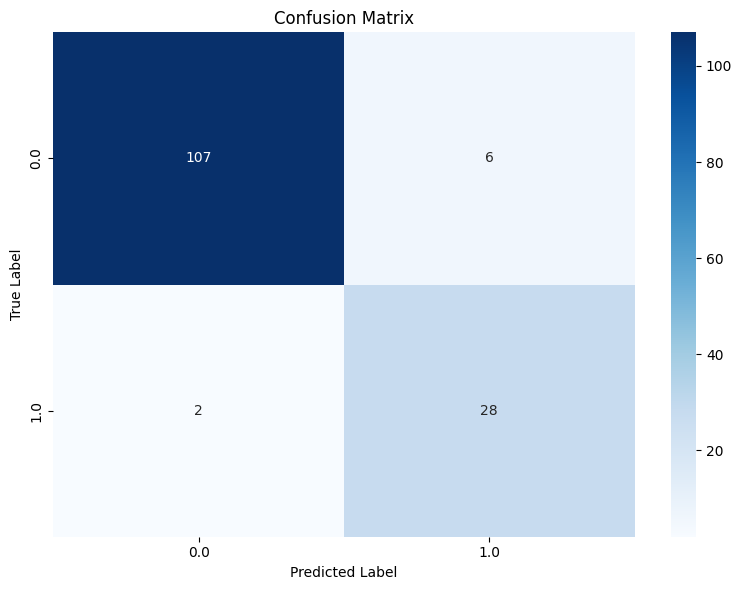

In [117]:

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
df_pred = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test.index)


df_pred = pd.concat([df_pred, X_test, df_proba], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,heavy-light,prob_class_0,prob_class_1
№,,,,,,,,,,,,
231,0.0,0.0,-29.405211,-26.059587,-25.656453,-25.987500,-0.331047,0.403135,3.345624,1.910423,0.543727,0.456273
241,0.0,0.0,-27.531697,-27.342804,-26.399652,-23.764096,2.635556,0.943153,0.188893,2.355377,0.554039,0.445961
251,0.0,0.0,-30.607958,-29.761420,-29.244007,-27.355263,1.888744,0.517413,0.846538,1.885054,0.546474,0.453526
252,0.0,0.0,-30.638555,-29.549602,-30.202411,-28.847503,1.354908,-0.652810,1.088954,0.569121,0.543727,0.456273
259,0.0,0.0,-31.825769,-31.744451,-30.933070,-30.344079,0.588991,0.811381,0.081318,1.146536,0.554039,0.445961
...,...,...,...,...,...,...,...,...,...,...,...,...
2067,1.0,1.0,-33.700000,-34.100000,-34.900000,NaN,NaN,-0.800000,-0.400000,NaN,0.438145,0.561855
2070,1.0,1.0,-33.100000,-33.300000,-33.900000,NaN,NaN,-0.600000,-0.200000,NaN,0.438145,0.561855
2080,0.0,0.0,-34.000000,-33.800000,NaN,NaN,NaN,NaN,0.200000,NaN,0.531673,0.468327


Лучше всего отработала модель, которая получать на вход необработанные данные. Буду использовать в сервисе ее 

---


# Модель для предсказания окисления

In [120]:
data_oxidation = df[['Sat', 'Aro', 'Res', 'Asph', 'B-Res', 'SB-Res', 'oxidation']]
data_oxidation

,Sat,Aro,Res,Asph,B-Res,SB-Res,oxidation
№,,,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,-26.044455,-26.144510,0.0
231,-29.405211,-26.059587,-25.656453,-25.987500,-24.599474,-26.713432,0.0
232,-30.561385,-28.704900,-28.300707,-27.909181,-28.165632,-28.435782,0.0
233,-31.602036,-30.805939,-27.730244,-28.712895,-28.099024,-27.361463,0.0
234,-27.340295,-30.127533,-29.691479,-28.045461,-29.676470,-29.706487,0.0
...,...,...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,NaN,NaN,NaN
2088,-33.900000,-33.100000,-34.900000,NaN,NaN,NaN,NaN
2089,-34.000000,-33.300000,NaN,NaN,NaN,NaN,NaN


In [ ]:

# выкинем строки с пропусками данных фракций, по которым нельзя определить, было ли окисление
# при каждом из процессов изменяется определнная фракция (несколько фракций), если я при разметке данных могу определить процесс с missing data, то его оставляем
# будем использовать методы МО, которые могут работать с пропусками
data_oxidation = data_oxidation.dropna(subset=['oxidation'])

# для предсказания будем использовать фракции (Sat, Aro, Res, Asph) и их разности. Если данных для Res нет, заполним их средним значением B-Res и SB-Res
mask = data_oxidation['Res'].isna()
data_oxidation.loc[mask, 'Res'] = (data_oxidation.loc[mask, 'B-Res'] + data_oxidation.loc[mask, 'SB-Res']) / 2
data_oxidation_pred = data_oxidation[['Sat', 'Aro', 'Res', 'Asph', 'oxidation']]
print("Пропуски в данных по окислению:\n", data_oxidation_pred.isna().sum())
data_oxidation_pred.value_counts('oxidation')

Пропуски в данных по окислению:
 Sat           0
Aro           0
Res           0
Asph         11
oxidation     0
dtype: int64


oxidation
0.0    488
1.0     73
Name: count, dtype: int64

Аналагично с прошлой моделью попробуем сначала не заполнять пропуски в данных, потом попробуем для заполнения данных IterativeImputer и KNNImputer. Применим SMOTE, обучим модели и сравним метрики. 

In [122]:
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import IterativeImputer



X_train, X_test_oxid, y_train, y_test_oxid = train_test_split(
    data_oxidation_pred.drop('oxidation', axis=1),
    data_oxidation_pred['oxidation'],
    test_size=0.2,
    random_state=42,
    stratify=data_oxidation_pred['oxidation']
) 

X_train_oxid, X_val_oxid, y_train_oxid, y_val_oxid = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 


X_train_oxid['asph-res'] = X_train_oxid['Asph'] - X_train_oxid['Res']
X_train_oxid['res-aro'] = X_train_oxid['Res'] - X_train_oxid['Aro']
X_train_oxid['aro-sat'] = X_train_oxid['Aro'] - X_train_oxid['Sat']


X_test_oxid['asph-res'] = X_test_oxid['Asph'] - X_test_oxid['Res']
X_test_oxid['res-aro'] = X_test_oxid['Res'] - X_test_oxid['Aro']
X_test_oxid['aro-sat'] = X_test_oxid['Aro'] - X_test_oxid['Sat']


X_val_oxid['asph-res'] = X_val_oxid['Asph'] - X_val_oxid['Res']
X_val_oxid['res-aro'] = X_val_oxid['Res'] - X_val_oxid['Aro']
X_val_oxid['aro-sat'] = X_val_oxid['Aro'] - X_val_oxid['Sat']


In [123]:
#загоняем в модель строки без пропусков

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='F1',  
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_oxid, y_train_oxid,
    eval_set=(X_val_oxid, y_val_oxid),
    verbose=100, 

)


y_pred = model.predict(X_test_oxid)
y_pred_proba = model.predict_proba(X_test_oxid)  


print("macro_f1",  f1_score(y_test_oxid, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test_oxid, y_pred))


model.save_model("catboost_multiclass_oxidation_no_imputer.cbm")


0:	learn: 0.6966292	test: 0.7500000	best: 0.7500000 (0)	total: 3.03ms	remaining: 1.51s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9230769231
bestIteration = 6

Shrink model to first 7 iterations.
macro_f1 0.946773433820066

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        98
         1.0       0.83      1.00      0.91        15

    accuracy                           0.97       113
   macro avg       0.92      0.98      0.95       113
weighted avg       0.98      0.97      0.97       113



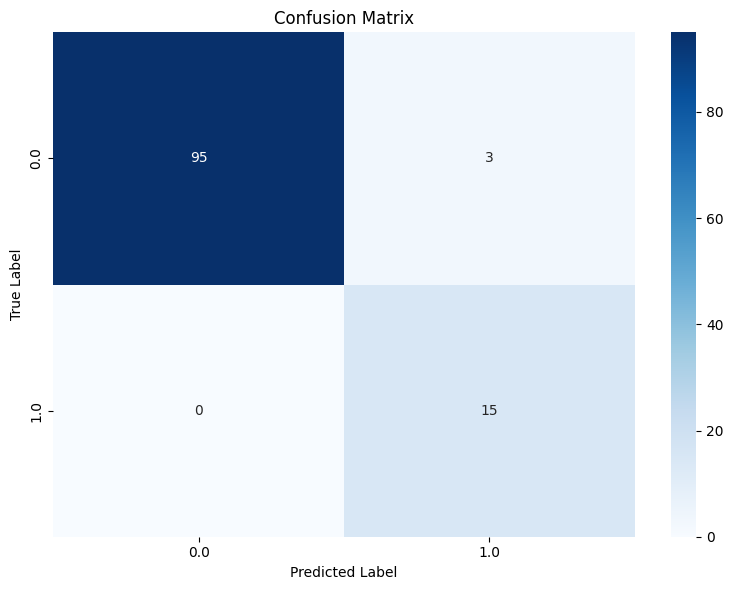

In [124]:
cm = confusion_matrix(y_test_oxid, y_pred)

# 2. Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_oxid), 
            yticklabels=np.unique(y_test_oxid))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [125]:
df_pred = pd.DataFrame({
    'y_true': y_test_oxid,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test_oxid.index)


df_pred = pd.concat([df_pred, X_test_oxid, df_proba], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,prob_class_0,prob_class_1
№,,,,,,,,,,,
370,0.0,1.0,-33.064461,-30.938381,-31.711236,-31.317876,0.39336,-0.772855,2.126080,0.348657,0.651343
566,0.0,1.0,-28.494846,-26.140000,-26.425000,-25.660000,0.76500,-0.285000,2.354846,0.449043,0.550957
587,0.0,1.0,-28.633277,-25.700000,-26.060000,-25.160000,0.90000,-0.360000,2.933277,0.398554,0.601446


0:	learn: 0.9741100	test: 0.8000000	best: 0.8000000 (0)	total: 3.27ms	remaining: 1.63s
100:	learn: 1.0000000	test: 0.8888889	best: 0.8888889 (46)	total: 280ms	remaining: 1.11s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8888888889
bestIteration = 46

Shrink model to first 47 iterations.
macro_f1 0.9008771929824562

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        98
         1.0       0.71      1.00      0.83        15

    accuracy                           0.95       113
   macro avg       0.86      0.97      0.90       113
weighted avg       0.96      0.95      0.95       113



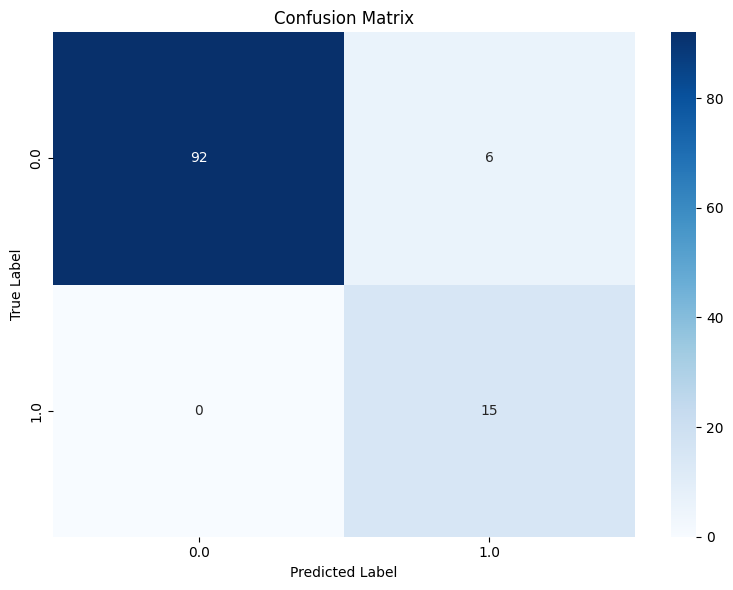

In [ ]:
#заполним пропуски с Iterative Imputer
IterImputer=IterativeImputer()
X_train_imputed = IterImputer.fit_transform(X_train_oxid) 
X_test_imputed = IterImputer.transform(X_test_oxid)
X_val_imputed = IterImputer.transform(X_val_oxid)

#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train_oxid)

feature_names = X_train_oxid.columns
X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_names)


X_train_resampled['asph-res'] = X_train_resampled['Asph'] - X_train_resampled['Res']
X_train_resampled['res-aro'] = X_train_resampled['Res'] - X_train_resampled['Aro']
X_train_resampled['aro-sat'] = X_train_resampled['Aro'] - X_train_resampled['Sat']

X_test_imputed['asph-res'] = X_test_imputed['Asph'] - X_test_imputed['Res']
X_test_imputed['res-aro'] = X_test_imputed['Res'] - X_test_imputed['Aro']
X_test_imputed['aro-sat'] = X_test_imputed['Aro'] - X_test_imputed['Sat']

X_val_oxid['asph-res'] = X_val_oxid['Asph'] - X_val_oxid['Res']
X_val_oxid['res-aro'] = X_val_oxid['Res'] - X_val_oxid['Aro']
X_val_oxid['aro-sat'] = X_val_oxid['Aro'] - X_val_oxid['Sat']

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='F1',              
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_val_imputed, y_val_oxid),
    verbose=100, 

)


y_pred = model.predict(X_test_imputed)
y_pred_proba = model.predict_proba(X_test_imputed)  


print("macro_f1",  f1_score(y_test_oxid, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test_oxid, y_pred))


cm = confusion_matrix(y_test_oxid, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_oxid), 
            yticklabels=np.unique(y_test_oxid))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

model.save_model("catboost_oxidation_iterative_imputer.cbm")


In [127]:
df_pred = pd.DataFrame({
    'y_true': y_test_oxid,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test_oxid.index)


df_pred = pd.concat([df_pred, X_test_oxid, df_proba], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,prob_class_0,prob_class_1
№,,,,,,,,,,,
285,0.0,1.0,-29.099318,-30.019779,-30.203761,-29.680284,0.523478,-0.183982,-0.920461,0.330243,0.669757
370,0.0,1.0,-33.064461,-30.938381,-31.711236,-31.317876,0.393360,-0.772855,2.126080,0.042353,0.957647
566,0.0,1.0,-28.494846,-26.140000,-26.425000,-25.660000,0.765000,-0.285000,2.354846,0.052319,0.947681
587,0.0,1.0,-28.633277,-25.700000,-26.060000,-25.160000,0.900000,-0.360000,2.933277,0.050822,0.949178
1431,0.0,1.0,-29.174492,-29.602655,-29.840764,-29.521899,0.318865,-0.238109,-0.428163,0.114764,0.885236
1917,0.0,1.0,-31.100000,-28.200000,-28.950000,-28.700000,0.250000,-0.750000,2.900000,0.152113,0.847887


KKNImputer

In [133]:
from sklearn.impute import KNNImputer



knn_imputer=KNNImputer(n_neighbors=5)

X_train_knn_imputed = knn_imputer.fit_transform(X_train_oxid) 
X_test_knn_imputed = knn_imputer.transform(X_test_oxid)
X_val_knn_imputed = knn_imputer.transform(X_val_oxid)

    
#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_knn_imputed, y_train_oxid)


feature_names = X_train_oxid.columns
X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_knn_imputed = pd.DataFrame(X_test_knn_imputed, columns=feature_names)
X_val_knn_imputed = pd.DataFrame(X_val_knn_imputed, columns=feature_names)

X_train_resampled['asph-res'] = X_train_resampled['Asph'] - X_train_resampled['Res']
X_train_resampled['res-aro'] = X_train_resampled['Res'] - X_train_resampled['Aro']
X_train_resampled['aro-sat'] = X_train_resampled['Aro'] - X_train_resampled['Sat']  

X_test_knn_imputed['asph-res'] = X_test_knn_imputed['Asph'] - X_test_knn_imputed['Res']
X_test_knn_imputed['res-aro'] = X_test_knn_imputed['Res'] - X_test_knn_imputed['Aro']
X_test_knn_imputed['aro-sat'] = X_test_knn_imputed['Aro'] - X_test_knn_imputed['Sat']

X_val_knn_imputed['asph-res'] = X_val_knn_imputed['Asph'] - X_val_knn_imputed['Res']
X_val_knn_imputed['res-aro'] = X_val_knn_imputed['Res'] - X_val_knn_imputed['Aro']
X_val_knn_imputed['aro-sat'] = X_val_knn_imputed['Aro'] - X_val_knn_imputed['Sat']


0:	learn: 0.9727558	test: 0.9453763	best: 0.9453763 (0)	total: 4.65ms	remaining: 2.32s
100:	learn: 1.0000000	test: 0.9681917	best: 0.9681917 (39)	total: 440ms	remaining: 1.74s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9681917211
bestIteration = 39

Shrink model to first 40 iterations.

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96        98
         1.0       0.68      1.00      0.81        15

    accuracy                           0.94       113
   macro avg       0.84      0.96      0.89       113
weighted avg       0.96      0.94      0.94       113



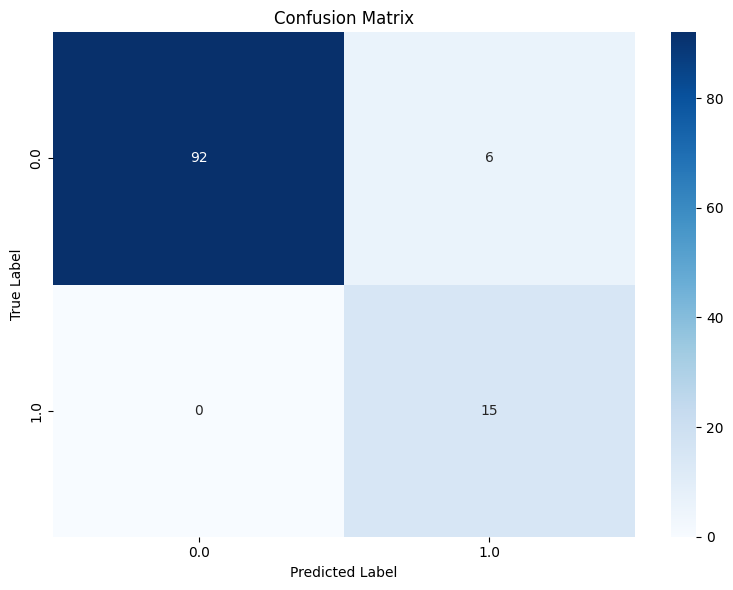

In [136]:

from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='TotalF1',              
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_val_knn_imputed, y_val_oxid),
    verbose=100,
 
)


y_pred = model.predict(X_test_knn_imputed)
y_pred_proba = model.predict_proba(X_test_knn_imputed)  



print("\nClassification Report:")
print(classification_report(y_test_oxid, y_pred))


#model.save_model("catboost_oxid_knn_imputer.cbm")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_oxid), 
            yticklabels=np.unique(y_test_oxid))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


In [138]:
df_pred = pd.DataFrame({
    'y_true': y_test_oxid,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test_oxid.index)


df_pred = pd.concat([df_pred, X_test_oxid, df_proba], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,asph-res,res-aro,aro-sat,prob_class_0,prob_class_1
№,,,,,,,,,,,
285,0.0,1.0,-29.099318,-30.019779,-30.203761,-29.680284,0.523478,-0.183982,-0.920461,0.306979,0.693021
370,0.0,1.0,-33.064461,-30.938381,-31.711236,-31.317876,0.393360,-0.772855,2.126080,0.090369,0.909631
553,0.0,1.0,-29.440000,-27.750000,-28.520000,NaN,NaN,-0.770000,1.690000,0.040433,0.959567
566,0.0,1.0,-28.494846,-26.140000,-26.425000,-25.660000,0.765000,-0.285000,2.354846,0.096200,0.903800
587,0.0,1.0,-28.633277,-25.700000,-26.060000,-25.160000,0.900000,-0.360000,2.933277,0.076558,0.923442
1431,0.0,1.0,-29.174492,-29.602655,-29.840764,-29.521899,0.318865,-0.238109,-0.428163,0.200939,0.799061
1917,0.0,1.0,-31.100000,-28.200000,-28.950000,-28.700000,0.250000,-0.750000,2.900000,0.187548,0.812452


Опять сработала лучше всего модель с сырыми данными

---
# Модель для предсказания миграции (приход флюида)

In [5]:
data_migration = df[['Sat', 'Aro', 'Res', 'Asph', 'B-Res', 'SB-Res', 'min(heavy)-min(light)', 'min(heavy)-max(light)', 'migration_in']]
data_migration

,Sat,Aro,Res,Asph,B-Res,SB-Res,min(heavy)-min(light),min(heavy)-max(light),migration_in
№,,,,,,,,,
230,-27.652583,-26.061426,-26.094482,-25.708339,-26.044455,-26.144510,1.558101,-0.033057,0.0
231,-29.405211,-26.059587,-25.656453,-25.987500,-24.599474,-26.713432,3.417711,0.072087,1.0
232,-30.561385,-28.704900,-28.300707,-27.909181,-28.165632,-28.435782,2.260678,0.404193,1.0
233,-31.602036,-30.805939,-27.730244,-28.712895,-28.099024,-27.361463,2.889142,2.093045,1.0
234,-27.340295,-30.127533,-29.691479,-28.045461,-29.676470,-29.706487,0.436054,-2.351184,0.0
...,...,...,...,...,...,...,...,...,...
2087,-32.900000,-32.900000,-32.300000,NaN,NaN,NaN,NaN,NaN,NaN
2088,-33.900000,-33.100000,-34.900000,NaN,NaN,NaN,NaN,NaN,NaN
2089,-34.000000,-33.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# для предсказания будем использовать только строки, где известны все фракции (Sat, Aro, Res, Asph)
# выкинем строки с пропусками данных фракций, по которым нельзя определить, была ли миграция
# при каждом из процессов изменяется определнная фракция (несколько фракций), если я при разметке данных могу определить процесс с missing data, то его оставляем
# будем использовать методы МО, которые могут работать с пропусками
data_migration = data_migration.dropna(subset=['migration_in'])

# для предсказания будем использовать фракции (Sat, Aro, Res, Asph) и их разности. Если данных для Res нет, заполним их средним значением B-Res и SB-Res
mask = data_migration['Res'].isna()
data_migration.loc[mask, 'Res'] = (data_migration.loc[mask, 'B-Res'] + data_migration.loc[mask, 'SB-Res']) / 2
data_migration_pred = data_migration[['Sat', 'Aro', 'Res', 'Asph', 'min(heavy)-min(light)', 'min(heavy)-max(light)', 'migration_in']]
print("Пропуски в данных по биодеградации:\n", data_migration_pred.isna().sum())
data_migration_pred.value_counts('migration_in')

Пропуски в данных по биодеградации:
 Sat                       1
Aro                       1
Res                      12
Asph                     18
min(heavy)-min(light)    28
min(heavy)-max(light)    28
migration_in              0
dtype: int64


migration_in
0.0    519
1.0     59
Name: count, dtype: int64

In [7]:
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import IterativeImputer



X_train, X_test, y_train, y_test = train_test_split(
    data_migration_pred.drop('migration_in', axis=1),
    data_migration_pred['migration_in'],
    test_size=0.2,
    random_state=42,
    stratify=data_migration_pred['migration_in']
) 

X_train['asph-res'] = X_train['Asph'] - X_train['Res']
X_train['res-aro'] = X_train['Res'] - X_train['Aro']
X_train['aro-sat'] = X_train['Aro'] - X_train['Sat']
#X_train['heavy-light'] = ((X_train['Asph'] + X_train['Res']) / 2) - ((X_train['Sat'] + X_train['Aro']) / 2)
#X_train['asph-aro'] = X_train['Asph'] - X_train['Aro']
#X_train['asph-sat'] = X_train['Asph'] - X_train['Sat']
#X_train['res-sat'] = X_train['Res'] - X_train['Sat']





X_test['asph-res'] = X_test['Asph'] - X_test['Res']
X_test['res-aro'] = X_test['Res'] - X_test['Aro']
X_test['aro-sat'] = X_test['Aro'] - X_test['Sat']
#X_test['heavy-light'] = ((X_test['Asph'] + X_test['Res']) / 2) - ((X_test['Sat'] + X_test['Aro']) / 2)
#X_test['asph-aro'] = X_test['Asph'] - X_test['Aro']
#X_test['asph-sat'] = X_test['Asph'] - X_test['Sat']
#X_test['res-sat'] = X_test['Res'] - X_test['Sat']



In [18]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

 #загоняем в модель строки без пропусков
X_train_, X_val, y_train_, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 


model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=3,
    loss_function='Logloss',          
    eval_metric='Logloss',  
    auto_class_weights='Balanced',              
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_, y_train_,
    eval_set=(X_val, y_val),
    verbose=100,

)


y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # вероятности по каждому классу



threshold = 0.6
y_pred_new = pd.DataFrame((y_pred_proba[:,1] > threshold).astype(int), columns=['y_pred_new'], index=X_test.index)

print("weighted_f1",  f1_score(y_test, y_pred_new, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


model.save_model("catboost_in_migration_no_imputer.cbm")


0:	learn: 0.6252159	test: 0.6278273	best: 0.6278273 (0)	total: 2.44ms	remaining: 731ms
100:	learn: 0.0481807	test: 0.1095623	best: 0.1095623 (100)	total: 369ms	remaining: 727ms
200:	learn: 0.0209209	test: 0.0750929	best: 0.0750929 (200)	total: 678ms	remaining: 334ms
299:	learn: 0.0126728	test: 0.0642343	best: 0.0642343 (299)	total: 902ms	remaining: 0us

bestTest = 0.06423428557
bestIteration = 299

weighted_f1 0.8620689655172413

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.94      0.97       104
         1.0       0.65      0.92      0.76        12

    accuracy                           0.94       116
   macro avg       0.82      0.93      0.86       116
weighted avg       0.95      0.94      0.94       116



In [168]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,min(heavy)-min(light),56.425335
1,res-aro,14.786186
2,aro-sat,11.188770
3,min(heavy)-max(light),9.281857
4,Sat,2.064803
5,asph-res,2.031769
6,Res,1.806739
7,Aro,1.382809
8,Asph,1.031732


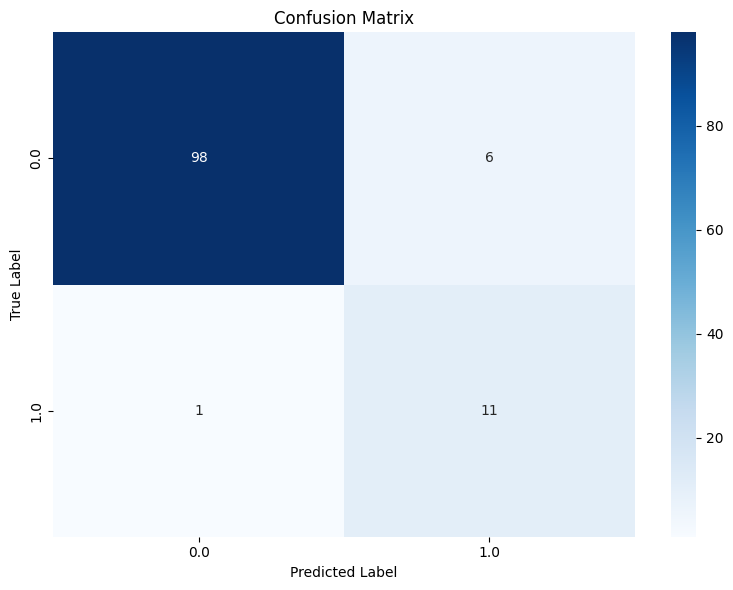

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_new)

# 2. Визуализация

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [13]:

df_pred = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred.reshape(-1, ),
})


prob_columns = [f'prob_class_{i}' for i in range(y_pred_proba.shape[1])]
df_proba = pd.DataFrame(y_pred_proba, columns=prob_columns, index=X_test.index)


df_pred = pd.concat([df_pred, X_test, df_proba, y_pred_new], axis=1)

misclassified = df_pred[df_pred['y_true'] != df_pred['y_pred']]
misclassified.sort_index()

,y_true,y_pred,Sat,Aro,Res,Asph,min(heavy)-min(light),min(heavy)-max(light),asph-res,res-aro,aro-sat,prob_class_0,prob_class_1,y_pred_new
№,,,,,,,,,,,,,,
373,0.0,1.0,-30.928362,-29.464349,-29.530173,-27.391338,1.398189,-0.065824,2.138835,-0.065824,1.464013,0.238203,0.761797,1
590,0.0,1.0,-27.770000,-26.100000,-26.345000,-24.740000,1.425000,-0.245000,1.605000,-0.245000,1.670000,0.303342,0.696658,1
653,1.0,0.0,-30.380000,-30.470000,-29.240000,-28.310000,1.230000,1.140000,0.930000,1.230000,-0.090000,0.678421,0.321579,0
1820,0.0,1.0,-29.980000,-30.460000,-29.065000,-29.010000,1.395000,0.915000,0.055000,1.395000,-0.480000,0.020758,0.979242,1
2035,0.0,1.0,-28.860000,-28.700000,-27.330000,-27.410000,1.450000,1.290000,-0.080000,1.370000,0.160000,0.015568,0.984432,1
2037,0.0,1.0,-28.910000,-28.670000,-27.140000,-27.580000,1.330000,1.090000,-0.440000,1.530000,0.240000,0.150379,0.849621,1
2057,0.0,1.0,-30.450000,-28.590000,-28.460000,-28.980000,1.470000,-0.390000,-0.520000,0.130000,1.860000,0.256683,0.743317,1


0:	learn: 0.9699880	test: 0.7619048	best: 0.7619048 (0)	total: 4.46ms	remaining: 2.22s
100:	learn: 0.9987937	test: 1.0000000	best: 1.0000000 (93)	total: 349ms	remaining: 1.38s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1
bestIteration = 93

Shrink model to first 94 iterations.
macro_f1 0.8781512605042017

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97       104
         1.0       0.69      0.92      0.79        12

    accuracy                           0.95       116
   macro avg       0.84      0.93      0.88       116
weighted avg       0.96      0.95      0.95       116



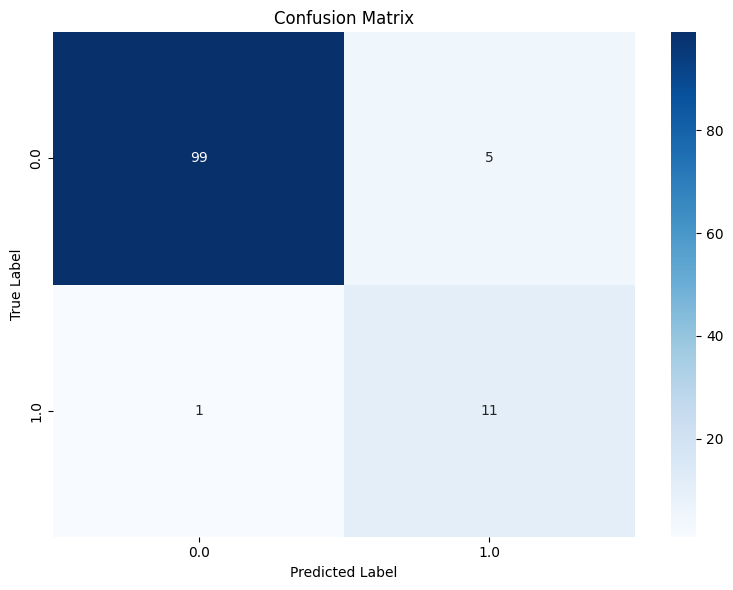

In [177]:
#заполним пропуски с Iterative Imputer
IterImputer=IterativeImputer()
X_train_imputed = IterImputer.fit_transform(X_train) 
X_test_imputed = IterImputer.transform(X_test)
X_val_imputed = IterImputer.transform(X_val)

#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

feature_names = X_train.columns
X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_names)
X_val_imputed = pd.DataFrame(X_val_imputed, columns=feature_names)


X_train_resampled['asph-res'] = X_train_resampled['Asph'] - X_train_resampled['Res']
X_train_resampled['res-aro'] = X_train_resampled['Res'] - X_train_resampled['Aro']
X_train_resampled['aro-sat'] = X_train_resampled['Aro'] - X_train_resampled['Sat']

X_test_imputed['asph-res'] = X_test_imputed['Asph'] - X_test_imputed['Res']
X_test_imputed['res-aro'] = X_test_imputed['Res'] - X_test_imputed['Aro']
X_test_imputed['aro-sat'] = X_test_imputed['Aro'] - X_test_imputed['Sat']

X_val_imputed['asph-res'] = X_val_imputed['Asph'] - X_val_imputed['Res']
X_val_imputed['res-aro'] = X_val_imputed['Res'] - X_val_imputed['Aro']
X_val_imputed['aro-sat'] = X_val_imputed['Aro'] - X_val_imputed['Sat']


model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='F1',              
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_val_imputed, y_val),
    verbose=100, 

)


y_pred = model.predict(X_test_imputed)
y_pred_proba = model.predict_proba(X_test_imputed)  


print("macro_f1",  f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

model.save_model("catboost_in_migration_iterative_imputer.cbm")


0:	learn: 0.9566202	test: 0.9317581	best: 0.9317581 (0)	total: 3.55ms	remaining: 1.77s
100:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (76)	total: 419ms	remaining: 1.66s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1
bestIteration = 76

Shrink model to first 77 iterations.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98       104
         1.0       0.73      0.92      0.81        12

    accuracy                           0.96       116
   macro avg       0.86      0.94      0.90       116
weighted avg       0.96      0.96      0.96       116



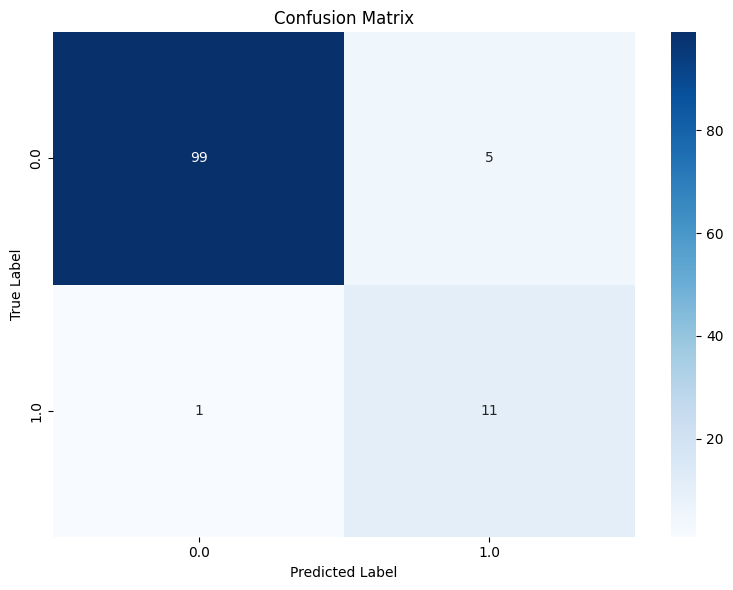

In [178]:
from sklearn.impute import KNNImputer



knn_imputer=KNNImputer(n_neighbors=5)

X_train_knn_imputed = knn_imputer.fit_transform(X_train) 
X_test_knn_imputed = knn_imputer.transform(X_test)
X_val_knn_imputed = knn_imputer.transform(X_val)

    
#сгенерируем синтетические данные с помощью SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_knn_imputed, y_train)


feature_names = X_train.columns
X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_knn_imputed = pd.DataFrame(X_test_knn_imputed, columns=feature_names)
X_val_knn_imputed = pd.DataFrame(X_val_knn_imputed, columns=feature_names)

X_train_resampled['asph-res'] = X_train_resampled['Asph'] - X_train_resampled['Res']
X_train_resampled['res-aro'] = X_train_resampled['Res'] - X_train_resampled['Aro']
X_train_resampled['aro-sat'] = X_train_resampled['Aro'] - X_train_resampled['Sat']  

X_test_knn_imputed['asph-res'] = X_test_knn_imputed['Asph'] - X_test_knn_imputed['Res']
X_test_knn_imputed['res-aro'] = X_test_knn_imputed['Res'] - X_test_knn_imputed['Aro']
X_test_knn_imputed['aro-sat'] = X_test_knn_imputed['Aro'] - X_test_knn_imputed['Sat']

X_val_knn_imputed['asph-res'] = X_val_knn_imputed['Asph'] - X_val_knn_imputed['Res']
X_val_knn_imputed['res-aro'] = X_val_knn_imputed['Res'] - X_val_knn_imputed['Aro']
X_val_knn_imputed['aro-sat'] = X_val_knn_imputed['Aro'] - X_val_knn_imputed['Sat']



from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',          
    eval_metric='TotalF1',              
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100,
    random_seed=42
)


model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_val_knn_imputed, y_val),
    verbose=100,
 
)


y_pred = model.predict(X_test_knn_imputed)
y_pred_proba = model.predict_proba(X_test_knn_imputed)  



print("\nClassification Report:")
print(classification_report(y_test, y_pred))


#model.save_model("catboost_oxid_knn_imputer.cbm")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
